gingru의 confidence check

he init을 하면 xavior보다 더 confident해진다고 함
즉 0과 1에 모여 있는 확률 값

실제로 그런지 확인해야 한다

일단 첫 부분은 he init을 한 모델을 로드한 것

두번째 부분은 xavior init을 한 모델을 로드한 것

In [1]:
import torch
import os
from tqdm import tqdm

device = torch.device('cpu')
batch_size = 32
embedding_dim = 32
gin_hidden_channel = 32
gin_layers=2
gru_hidden_channel=64

num_nodes=60

learning_rate = 0.001
scheduler_patience = 5
early_stopping_patience = 10


In [2]:
cur_dir = os.getcwd()
root = os.path.join(cur_dir, 'data_tensor_cache')
model_path = os.path.join(cur_dir, 'checkpoints', 'gingru', 'real', '1218_gingru_epoch_39_loss_0.3741.pth')
mi_dict_path = os.path.join(root, 'data', 'mi_dict_static.pickle')

In [3]:
from teds_tensor_dataset import TEDSTensorDataset
dataset = TEDSTensorDataset(root)

col_list, col_dims, ad_col_index, dis_col_index = dataset.col_info

from utils.processing_utils import train_test_split_customed
train_loader, val_loader, test_loader = train_test_split_customed(dataset, batch_size)

/opt/miniconda3/envs/pyg_2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


저장되어 있는 전처리된 데이터가 있습니다. 해당 데이터를 불러오는 중..
불러오기 완료
Train Set Size: 975896
Valid Set Size: 209119
Test Set Size: 209123


In [4]:
from models.gingru_for_explain import GinGruForExplain2
from models.gin_gru import GinGru

model = GinGru(
    batch_size=batch_size,
    col_list=col_list,
    col_dims=col_dims,
    ad_col_index=ad_col_index,
    dis_col_index=dis_col_index,
    embedding_dim=embedding_dim,
    gin_hidden_channel=gin_hidden_channel,
    train_eps=True,
    gin_layers=gin_layers,
    gru_hidden_channel=gru_hidden_channel
)
model

GinGru(
  (dropout_mlp): Dropout(p=0.2, inplace=False)
  (dropout_gin_out): Dropout(p=0.2, inplace=False)
  (dropout_after_gru): Dropout(p=0.2, inplace=False)
  (entity_embedding_layer): EntityEmbeddingBatch3(
    (embedding_layer): Embedding(1143, 32)
  )
  (gin_layers): ModuleList(
    (0-1): 2 x GINConv(nn=Sequential(
      (0): Linear(in_features=32, out_features=32, bias=True)
      (1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
      (4): Linear(in_features=32, out_features=32, bias=True)
    ))
  )
  (gru_layer): GRU(64, 64)
  (classifier_b): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
  (gin_nn_input): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropo

In [5]:
def load_checkpoint(model, optimizer, scheduler, filename, map_location=None):
    checkpoint = torch.load(filename, map_location=map_location)

    # --- Load states ---
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_loss = checkpoint['best_loss']

    return start_epoch, best_loss

In [6]:
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau
from utils.early_stopper import EarlyStopper

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = ReduceLROnPlateau(optimizer, "min", patience=scheduler_patience)
early_stopper = EarlyStopper(patience=early_stopping_patience)

load_checkpoint(model, optimizer, scheduler, model_path)
model = model.to(device)
model = model.eval()

In [8]:
from utils.processing_utils import mi_edge_index_batched

edge_index = mi_edge_index_batched(batch_size,
                                   num_nodes=num_nodes,
                                   mi_dict_path=mi_dict_path)

edge_index = edge_index.to(device)



In [28]:
edge_index = mi_edge_index_batched(1,
                                   num_nodes=num_nodes,
                                   mi_dict_path=mi_dict_path)

ad_edge = edge_index[:, :int(952/2)]
dis_edge = edge_index[:, int(952/2):] - 60

ad_edge.allclose(dis_edge)
from utils.processing_utils import fully_connected_edge_index_batched

edge_index_f = fully_connected_edge_index_batched(60, 32)
print(edge_index_f.shape)

torch.Size([2, 113280])


In [18]:
result_list = []
for batch in tqdm(test_loader):
    x_batch, y_batch, los_batch = batch
    logits = model(x_batch, los_batch, edge_index, device)
    probs = torch.sigmoid(logits)
    result_list.append(probs)

  6%|▌         | 405/6535 [00:03<00:49, 123.43it/s]


KeyboardInterrupt: 

In [8]:
probs_flat = torch.cat(result_list)

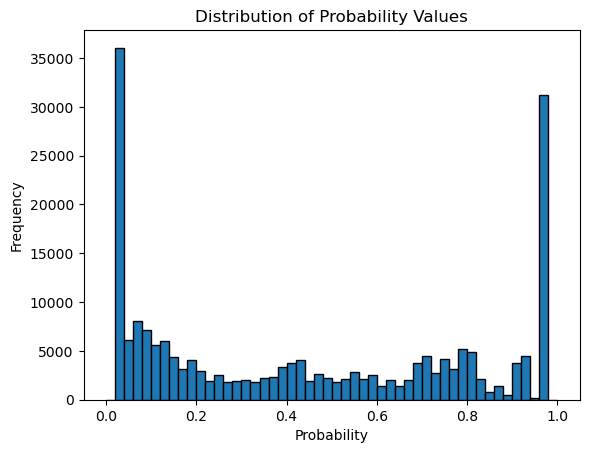

In [9]:
import matplotlib.pyplot as plt

# probs: 모델의 출력에 sigmoid를 적용한 확률 값들 (PyTorch Tensor)
probs_flat = probs_flat.detach().cpu().numpy().flatten()

plt.hist(probs_flat, bins=50, range=(0, 1), edgecolor='black')
plt.title('Distribution of Probability Values')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.show()

In [10]:
def calculate_entropy(p):
    # 수치적 안정성을 위해 아주 작은 값(1e-7)을 더해줌
    epsilon = 1e-7
    entropy = -(p * torch.log(p + epsilon) + (1 - p) * torch.log(1 - p + epsilon))
    return entropy.mean().item()

avg_entropy = calculate_entropy(probs)
print(f"평균 엔트로피: {avg_entropy:.4f}")

평균 엔트로피: 0.3459


In [11]:
print(f"표준편차: {probs.std().item():.4f}")
print(f"0.1 이하 개수: {(probs < 0.1).float().mean().item() * 100:.2f}%")
print(f"0.9 이상 개수: {(probs > 0.9).float().mean().item() * 100:.2f}%")

표준편차: 0.3687
0.1 이하 개수: 40.62%
0.9 이상 개수: 18.75%


In [12]:
from models import gin_gru_before_he_drop
model2 = gin_gru_before_he_drop.GinGru(
    batch_size=batch_size,
    col_list=col_list,
    col_dims=col_dims,
    ad_col_index=ad_col_index,
    dis_col_index=dis_col_index,
    embedding_dim=embedding_dim,
    gin_hidden_channel=gin_hidden_channel,
    train_eps=True,
    gin_layers=gin_layers,
    gru_hidden_channel=gru_hidden_channel
)
model2

GinGru(
  (entity_embedding_layer): EntityEmbeddingBatch3(
    (embedding_layer): Embedding(1143, 32)
  )
  (gin_layers): ModuleList(
    (0-1): 2 x GINConv(nn=Sequential(
      (0): Linear(in_features=32, out_features=32, bias=True)
      (1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Linear(in_features=32, out_features=32, bias=True)
    ))
  )
  (gru_layer): GRU(64, 64)
  (classifier_b): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [13]:
def load_checkpoint(model, optimizer, scheduler, filename, map_location=None):
    checkpoint = torch.load(filename, map_location=map_location)

    # --- Load states ---
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_loss = checkpoint['best_loss']

    return start_epoch, best_loss

model_path_2 = os.path.join(cur_dir, 'checkpoints', 'gingru', 'real', 'best_gingru_epoch_6_loss_0.3761.pth')

load_checkpoint(model2, optimizer=optimizer, scheduler=scheduler, filename=model_path_2)
model2 = model2.to(device)
model2 = model2.eval()

In [14]:
result_list = []
for batch in tqdm(test_loader):
    x_batch, y_batch, los_batch = batch
    logits = model2(x_batch, los_batch, edge_index, device)
    probs = torch.sigmoid(logits)
    result_list.append(probs)

100%|██████████| 6535/6535 [00:56<00:00, 115.40it/s]


In [15]:
probs_flat = torch.cat(result_list)

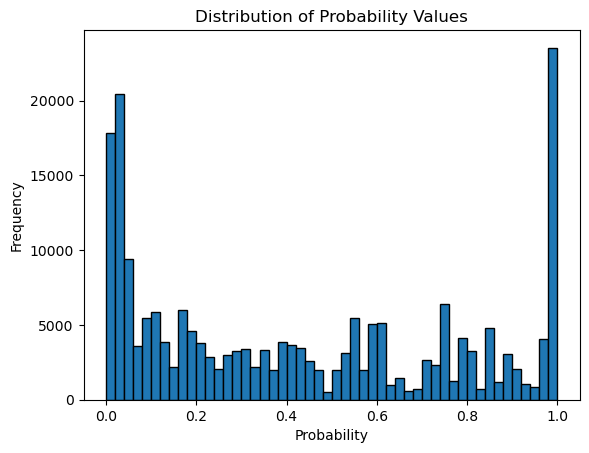

In [16]:
import matplotlib.pyplot as plt

# probs: 모델의 출력에 sigmoid를 적용한 확률 값들 (PyTorch Tensor)
probs_flat = probs_flat.detach().cpu().numpy().flatten()

plt.hist(probs_flat, bins=50, range=(0, 1), edgecolor='black')
plt.title('Distribution of Probability Values')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.show()

In [17]:
def calculate_entropy(p):
    # 수치적 안정성을 위해 아주 작은 값(1e-7)을 더해줌
    epsilon = 1e-7
    entropy = -(p * torch.log(p + epsilon) + (1 - p) * torch.log(1 - p + epsilon))
    return entropy.mean().item()

avg_entropy = calculate_entropy(probs)
print(f"평균 엔트로피: {avg_entropy:.4f}")

평균 엔트로피: 0.3291


In [18]:
print(f"표준편차: {probs.std().item():.4f}")
print(f"0.1 이하 개수: {(probs < 0.1).float().mean().item() * 100:.2f}%")
print(f"0.9 이상 개수: {(probs > 0.9).float().mean().item() * 100:.2f}%")

표준편차: 0.3706
0.1 이하 개수: 37.50%
0.9 이상 개수: 18.75%
